# Flash Drought Indicators

This notebook will introduce two remote sensing datasets that we will be processing into flash drought indicators. 
* Solar-Induced Fluorescence (SIF) data from the [GOSIF dataset](https://globalecology.unh.edu/data/GOSIF.html)
* Root-zone Soil Moisture (SM) data from the [SMAP L4 Global 3-hourly 9 km dataset](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C3480440870-NSIDC_CPRD)

_It is assumed that you have already read or attended the lecture portion of this course session before starting this notebook to get the full context for the approach presented here._

### Why are we using these datasets?

The motivation for using SIF and SM data for detecting flash drought comes from an "impact-centric framework" developed by Koushan Mohammadi and Guiling Wang of the University of Connecticut. \[[3](https://doi.org/10.1073/pnas.2202767119)\]\[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\] Traditionally, drought was seen as a primarily climatological phenomenon where a deficit in precipitation and higher than normal temperatures were the key metrics used for detection \[[1](https://doi.org/10.46275/JOASC.2021.02.001)\]\[[2](https://doi.org/10.1002/wat2.1714)\]. Agricultural droughts are, however, assessed in terms of their impacts on cropland above any other factors, so the determination as to whether a precipitation deficit is material to crop growth depends on the crop type, existing soil moisture, and the climate of the growing region being studied. It is far more effective, therefore, to use land-process based metrics like SIF and SM to detect flash drought than it is to use metrics like temperature and precipitation. 

## I. Solar-Induced Chlorophyll Flourescence and the SIF Rapid Change Index (SIF-RCI)

SIF data can be thought of as a measure of the photosynthetic activity of plants in aggregate. The ARSET program has produced several courses on this data if you would like to learn more about this exciting measurement: [SIF Observations for Assessing Vegetation Changes Related to Floods, Drought, and Fire Impacts](https://www.earthdata.nasa.gov/learn/trainings/solar-induced-fluorescence-sif-observations-assessing-vegetation-changes-related). As most instruments capable of measuring SIF data from space right now are limited in terms of their spatial coverage and observational record, we will be relying on a gap-filled dataset called [GOSIF](https://globalecology.unh.edu/data/GOSIF.html) produced by Xing Li and Jingfeng Xiao of the University of New Hampshire (UNH). \[[11](https://doi.org/10.3390/rs11050517)\] Gap-filled data like GOSIF combines OCO-2 observations with a secondary source like Terra and Aqua MODIS to both fill in spatial gaps in the data and allow the SIF measurement to be extrapolated past the time range of the OCO-2 mission, which launched in 2014. Mohammadi and Wang use the GOME-2 and Contiguous SIF (CSIF) products in their own research as data sources, but GOSIF offers the same 8-day temporal resolution used in \[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\] and has publicly accessible data from 2000-2024.

In this first section, we will download a time range of GOSIF data from the UNH repository and unpack it into GeoTIFF format.

In [1]:
import os

from download import download_unpack_gosif
from tqdm.notebook import tqdm

year = 2017
# Our time series will cover the growing season from DOY 73-298, but to calculate the SIF-RCI for the year
# we need to download data going back to the beginning of the year.
doy_range = range(1, 298, 8)

output_dir = "data/gosif"
os.makedirs(output_dir, exist_ok=True)

gosif_geotiffs: list[str] = []
for doy in tqdm(doy_range, desc="Downloading granules"):
    fname = download_unpack_gosif(
        year,
        day=doy,
        output_dir=output_dir,
        verbose=False
    )
    if fname:
        gosif_geotiffs.append(fname)

## Looking at the SIF Data

Now that we have some GOSIF data, it's helpful to get an intuition for the measurement before we process it into a useful flash drought indicator. In the `data/gosif` directory, you will find a set of GeoTIFF images with the naming convention `GOSIF_{year}{day_of_year}.tif`. If you open one of these files in your preferred GIS software, you can see that it has global coverage over land with the exception of regions with year-round ice cover. In QGIS, the data is best viewed when taking the following additional steps (these instructions were tested with QGIS 3.44 LTS):

1. For our example, let's look at the file `GOSTIF_2017097.tif` which should be one of the files we downloaded above. Optionally, you can also load your preferred basemap. The source projection of the data is EPSG:4326, so you should use that CRS in the Project Properties if you are not using it already.
2. After loading the GeoTIFF, open the layer properties by double clicking the layer in the "Layers" panel.
3. Navigate to the "Transparency" tab and under the "Custom Transparency Options" click the "+" icon and in the table set From 32766 To 32767 as 100 Percent Transparent. Click Apply.
4. Go to the Symbology tab and choose "Singleband pseudocolor" as the "Render type". For the "Color ramp", we recommend "Greens" or "YlGn" (which is available under "All Color Ramps").
5. Set the Min and Max values according to your preference. The data is scaled by a factor of 10000 from the actual units (W/m²/sr/µm), so a range of -500 to 4000 corresponds to -0.05 to 0.4 W/m²/sr/µm.

If you followed the steps correctly, the data should look like this:
<div style="text-align:center">
  <img style="width:960px" src="inputs/GOSIF_QGIS_example.png" alt="A screenshot of a QGIS window showing a GOSIF granule overlayed on an Open Street Map base layer.">
</div>

### Understanding SIF

Unlike other vegetation indices such as NDVI, the SIF values reported in this dataset are an estimate of the average spectral radiance of plants due to chlorophyll fluorescence and is therefore sensitive to photosynthetic yield.  Superficially, this means that while SIF and NDVI both vary according to the season and vegetation class, the former responds more linearly to changes in Absorbed Photosynthetically Active Radiation (APAR) as the vegetation responds to changing environmental conditions. \[[5](https://doi.org/10.1016/j.rse.2015.06.008)\] The power of this measurement is that in theory it responds more quickly to changes in photosynthesis than a reflectance ratio, which often is just a proxy for greenness of vegetation. Flash droughts are characterized by their **rapid onset**, so it's often the case that they have already begun by the time plants turn brown.

SIF itself is estimated by detecting a faint signal in nanometer-wide Fraunhofer lines that can only be resolved by very spectrally sensitive spectrometers like OCO-2. For our analysis, the data is then interpolated using machine learning over the observational record of the MODIS instrument to produce the GOSIF product. \[[11](https://doi.org/10.3390/rs11050517)\] While negative values may at first seem not physically plausible, we occasionally see negative values for SIF due to the retrieval uncertainty. 

### Case Study: 2017 Northern Great Plains Flash Drought

In our first case study, we are looking at the Northern Great Plains region of the US and Canada defined in the Mohammadi and Wang paper as 45°-50°N and 106°-111°W \[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\]. This area is primarily a semi-arid steppe with grasslands and wheat and barley fields, interspersed with a few solitary mountain ranges containing mixed needleleaf/broadleaf forests. In the summer of 2017, a flash drought occurred that sparked wildfires resulting in an estimated $2.6 billion in agricultural losses. Let's use the data that we downloaded to get a sense of the onset of this flash drought.

To get the most out of SIF's greater sensitivity to changes in vegetation health, we need to look at the measurement in relation to its past behavior. In particular we can look at **SIF Anomaly**, the difference between the current SIF value on a given date and its historical mean. Since GOSIF is extrapolated over the record of MODIS, we have estimates going back to 2000 and this enables us to create a map of mean SIF over the period 2001-2020. To save time, we have already performed the computation of mean SIF over the Northern Great Plains region and saved the results in the `inputs/sif_increments_nplains` directory. If you would like to reproduce the data or produce it for a different region, please see the `3_appendix.ipynb` notebook. 

Using our mean SIF values and the GOSIF values for a single 8-day time step, we can look at SIF Anomaly over the region of interest for each time step in 2017 to see where the flash drought was more or less impactful. The cell below will start up an interactive visualization that allows you to flip through different 8-day steps to see how the event progressed. 
* **First, check out the locations of positive anomaly in April and May.** 
  * Using the basemap, can you identify the cropland and forest regions? 
  * Which land cover type experienced a significant (>0.1 W/m²/sr/µm) positive anomaly in early April?
  * Can you identify the approximate planting date in 2017 from this data?
* **Next, note the sudden development of a negative SIF anomaly in the northeast corner of the region in July.** 
  * Which land cover class is represented in the northeast corner of the region of interest?
  * Why would grasslands and croplands change from a positive (or neutral) SIF anomaly more quickly than forests?

In [3]:
import functools
import socketserver
import threading

from IPython.display import IFrame
from server import RangeHandler

PORT = 8000
handler = functools.partial(RangeHandler, directory=os.getcwd())

# Recreate the server if it doesn't exist yet OR if a non-range server is stale.
if not globals().get("_sif_server"):
    socketserver.TCPServer.allow_reuse_address = True
    _sif_server = socketserver.TCPServer(("127.0.0.1", PORT), handler)
    threading.Thread(target=_sif_server.serve_forever, daemon=True).start()

print(f"You can also open the map viewer in your browser at http://localhost:{PORT}/sif_map_viewer.html")
IFrame(src=f"http://127.0.0.1:{PORT}/sif_map_viewer.html?year=2017&doy=137", width=1024, height=720)

You can also open the map viewer in your browser at http://localhost:8000/sif_map_viewer.html


## Creating Time Series of SIF, SIF Standardized Anomaly and SIF-RCI

Now that we've retrieved and visualized our data, we can create a time series of the average SIF value over the region of interest and plot it compared to the mean climatology over the period 2001-2020. Furthermore to make SIF more useful as a drought _detection_ indicator, we want to represent the deviation from the expected seasonal growth cycle as a time series. The Z-score of the change in SIF between time steps, which can also be referred to as **SIF Standardized Anomaly**, is the statistical metric that will be used to detect this deviation. To go one step further, the **SIF-RCI** represents the accumuluation of positive or negative deviation from the normal seasonal growth pattern in SIF. We can set a threshold on SIF-RCI to indicate whether or not a drought is present in a region, and use the rate of change in RCI to determine if the event can be considered a _flash_ drought. 

We will again use the climatology information from  the pre-processed files in the `inputs/sif_increments_nplains` directory. The geotiffs in this directory are structured with four bands:

- Band 1: $\overline{\Delta \mathrm{SIF}_j}$, the mean increment of SIF for the jth 8-day window over the period 2001-2020
- Band 2: $\sigma_{\Delta \mathrm{SIF}_j}$, the standard deviation in the increment of SIF for the jth 8-day window over the period 2001-2020
- Band 3: $\overline{\mathrm{SIF}_j}$, the mean SIF for the jth 8-day window over the period 2001-2020
- Band 4: $\sigma_{\mathrm{SIF}_j}$, the standard deviation of SIF at time step j. We won't use this in this exercise, but we can use it to compute the Z-score of SIF later.

In this next cell, we will create a CSV file with the various time series we intend to use as flash drought indicators:
- $\mathrm{SIF}_{j, y}$, the SIF value from year $y$ (2017 in this case) and time window $j$. This is not used as a drought indicator on its own, but we will plot it anyways.
- $\overline{\mathrm{SIF}_j}$, this is a spatial averaging of the Band 3 climatology data mentioned above. It is also not a drought indicator on its own, and we will just use it for comparison in our first plot.
- $Z(j, y)$, "SIF Standardized Anomaly" or z-score for the jth 8-day window in year $y = 2017$
- $\mathrm{RCI}(j, y)$, the SIF Rapid Change Index (RCI) for the jth 8-day window in year $y = 2017$

The z-score or SIF Standardized Anomaly can be calculated as follows:

$$
Z(j, y) = \frac{\Delta \mathrm{SIF}_{j, y} - \overline{\Delta \mathrm{SIF}_j}}{\sigma_{\Delta \mathrm{SIF}_j}}
$$

We do this per grid cell over the region of interest and then spatially average the data to get the value in the time series.

Likewise, the SIF-RCI can be calculated in a piecewise recursive manner using the z-scores:

$$
\mathrm{RCI}(j, y) =
\begin{cases}
  \mathrm{RCI}(j-1, y) - \sqrt{|Z(j, y)| - 0.75},  & \text{if } Z(j, y) \lt -0.75, \\
  \mathrm{RCI}(j-1, y) + \sqrt{Z(j, y) - 0.75},    & \text{if } Z(j, y) \gt 0.75, \\
  0,                                               & \text{if } Z(j-1, y)*Z(j, y) \lt 0.
\end{cases}
$$

In [4]:
import csv
from datetime import datetime
from glob import glob

import numpy as np
import rasterio
from rasterio.windows import from_bounds

region_name = "nplains"
# Set the filename to use for the time series
time_series_fname = f"{region_name}_{year}_sif.csv"
# Get the climatology inputs produced by the appendix notebook
clim_geotiffs = sorted(glob(f"inputs/sif_increments_{region_name}/GOSIF_dSIF_clim_???.tif"))

# Northern Great Plains region of interest
# 45.00°-50.00°N, 106.00°-111.00°W
west, south, east, north = -111.0, 45.0, -106.0, 50.0

# The threshold and scale factor parameters come from the documentation: https://data.globalecology.unh.edu/data/GOSIF_v2/Fair_Data_Use_Policy_and_Readme_GOSIF_v2.pdf
# 32767 = water bodies, 32766 = ice/snow
gosif_data_thresh = 32765
# This value tells our code the conversion between pixel values in the GeoTIFF images to units of W/m^2/sr/μm
gosif_scale_factor = 0.0001

with rasterio.open(gosif_geotiffs[0]) as src:
    read_window = from_bounds(west, south, east, north, src.transform)
    read_window = read_window.round_offsets().round_lengths()


def read_roi(path: str) -> np.ndarray:
    """Read the ROI, mask non-data (water/ice/fill), scale to physical units."""
    with rasterio.open(path) as src:
        arr = src.read(1, window=read_window).astype("float64")
    arr[arr > gosif_data_thresh] = np.nan
    return arr * gosif_scale_factor


def compute_rci(
        z_jy_grid: np.ndarray,
        z_prev_grid: np.ndarray,
        rci_prev_grid: np.ndarray
) -> np.ndarray:
    """Compute the per grid cell SIF-RCI using the formula from above."""
    neg_anom = z_jy_grid < -0.75                  # Z(j,y) < -0.75       (case 1)
    pos_anom = z_jy_grid > 0.75                   # Z(j,y) >  0.75       (case 2)
    sign_change = (z_prev_grid * z_jy_grid) < 0   # Z(j-1,y)·Z(j,y) < 0  (case 3)

    neg_term = np.sqrt(np.where(neg_anom, np.abs(z_jy_grid) - 0.75, 0.0))
    pos_term = np.sqrt(np.where(pos_anom, z_jy_grid + 0.75, 0.0))

    rci_jy_grid = rci_prev_grid.copy()
    rci_jy_grid = np.where(neg_anom, rci_prev_grid - neg_term, rci_jy_grid)
    rci_jy_grid = np.where(pos_anom, rci_prev_grid + pos_term, rci_jy_grid)
    rci_jy_grid = np.where(sign_change, 0.0, rci_jy_grid)
    return rci_jy_grid


prev_grid: np.ndarray | None = None
# Initialize the arrays for the rows of our CSV
# The variable names correspond to what is mentioned in the description above
dates: list[datetime] = []
sif_jy: list[float] = []
mean_sif_j: list[float] = []
z_jy: list[float] = []
rci_jy: list[float] = []

# Recursive state carried between time windows for RCI.
# RCI(j0, y) = 0 and Z(j0, y) = 0 everywhere
# For simplicity, our incon j0 = DOY 1
rci_prev_grid: np.ndarray = np.zeros((read_window.height, read_window.width))
z_prev_grid: np.ndarray = np.zeros((read_window.height, read_window.width))

for j, geotiff in enumerate(gosif_geotiffs[1:], start=1):
    # Parse the date from the filename, e.g. GOSIF_2017073.tif = DOY 73
    doy = os.path.splitext(os.path.basename(geotiff))[0][-3:]
    dates.append(datetime.strptime(f"{year}{doy}", "%Y%j")) # noqa: DTZ007

    sif_grid = read_roi(geotiff)
    if j == 1:
        prev_grid = read_roi(gosif_geotiffs[j-1])
    # Get the SIF increment at j
    dsif_grid = sif_grid - prev_grid
    # Set the current raster to the previous for the next iteration
    prev_grid = sif_grid

    # Get the climatology input file produced by the appendix notebook
    clim_input = f"inputs/sif_increments_{region_name}/GOSIF_dSIF_clim_{doy}.tif"
    with rasterio.open(clim_input) as clim_src:
        mean_dsif_band = clim_src.read(1).astype(float)
        std_dsif_band = clim_src.read(2).astype(float)
        mean_sif_band = clim_src.read(3).astype(float)

    z_jy_grid = (dsif_grid - mean_dsif_band) / std_dsif_band

    rci_jy_grid = compute_rci(z_jy_grid, z_prev_grid, rci_prev_grid)
    z_prev_grid = z_jy_grid
    rci_prev_grid = rci_jy_grid

    rci_masked = np.where(np.isnan(z_jy_grid), np.nan, rci_jy_grid)

    # Compute the spatial average at the end
    sif_jy.append(float(np.nanmean(sif_grid)))
    mean_sif_j.append(float(np.nanmean(mean_sif_band)))
    z_jy.append(float(np.nanmean(z_jy_grid)))
    rci_jy.append(float(np.nanmean(rci_masked)))

# Save the output as a CSV so it can be used in the next notebook
csv_path = os.path.join("data", time_series_fname)
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["date", "sif", "mean_sif", "dsif_zscore", "sif_rci"])
    # We have 4 sig figs from the source data
    writer.writerows(
        zip(
            [d.strftime("%Y-%m-%d") for d in dates],
            [f"{sjy:.4f}" for sjy in sif_jy],
            [f"{msj:.4f}" for msj in mean_sif_j],
            [f"{zjy:.4f}" for zjy in z_jy],
            [f"{rjy:.4f}" for rjy in rci_jy],
        )
    )

print(f"Computed time series values for {len(dates)} granules and saved to {csv_path}")

Computed time series values for 37 granules and saved to data/nplains_2017_sif.csv


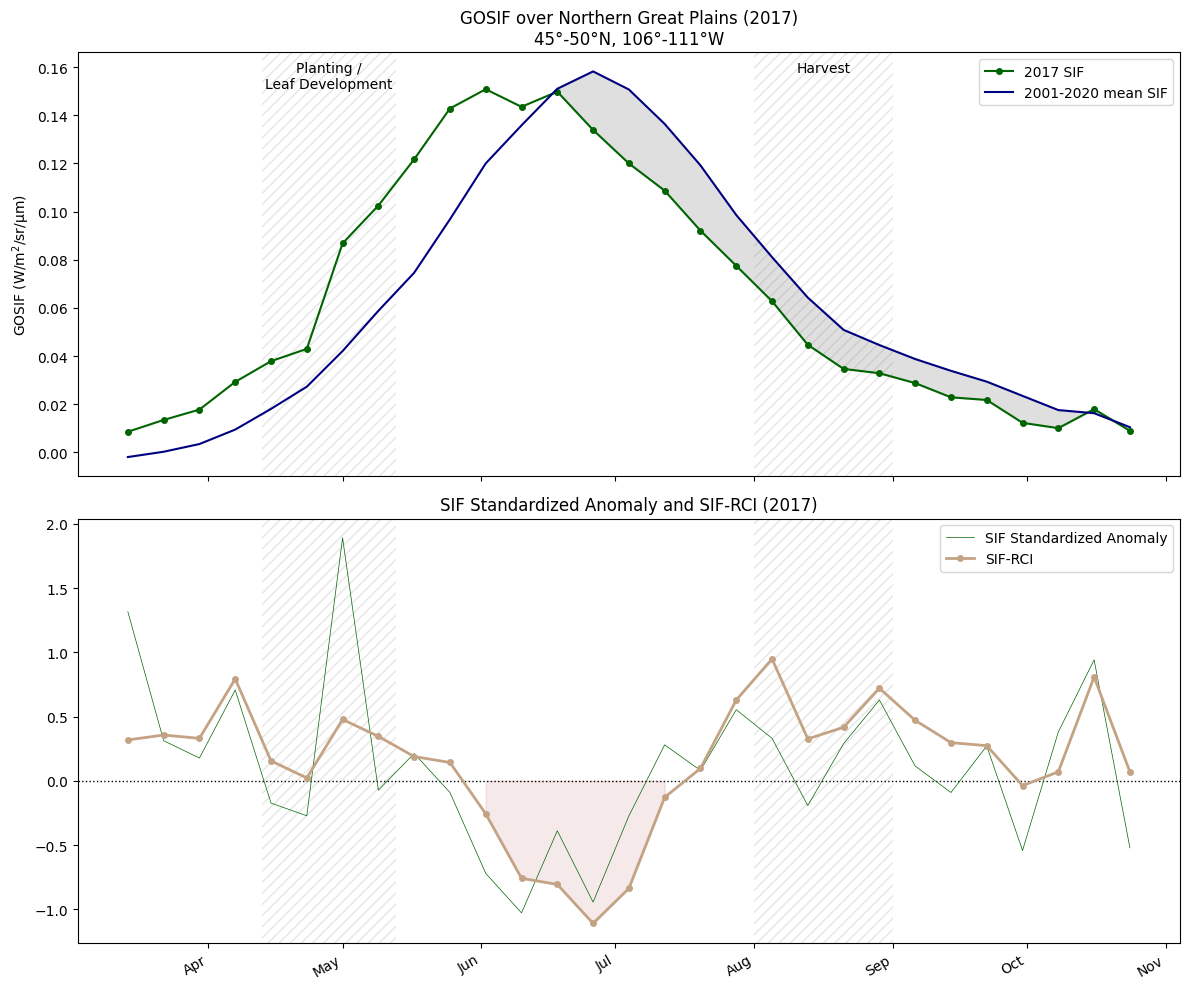

In [5]:
import csv

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

plot_doy_start = 73
plot_doy_end = 298

# Read the saved CSV
plot_dates = []
plot_sif: list[float] = []
plot_mean_sif: list[float] = []
plot2_zscore: list[float] = []
plot2_sifrci: list[float] = []
with open(csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["date"], "%Y-%m-%d") # noqa: DTZ007
        doy = int(pt_date.strftime("%j"))
        if doy < plot_doy_start or doy > plot_doy_end:
            continue
        plot_dates.append(pt_date)
        plot_sif.append(float(row["sif"]))
        plot_mean_sif.append(float(row["mean_sif"]))
        plot2_zscore.append(float(row["dsif_zscore"]))
        plot2_sifrci.append(float(row["sif_rci"]))

# In the first plot, let's highlight the region where 2017 observed SIF
# was below the mean SIF for that time of year
# Note that there are small "fudge factors" in this statement and the one below,
# these are not to be used for actual analysis but are just used to make the plots
# look better.
below_mean = [s < (m + 0.005) for s, m in zip(plot_sif, plot_mean_sif)]

# In the second plot, we can highlight the period where the SIF-RCI signal
# was indicating flash drought, i.e. it was persistently below 0
flash_drought = [r < -0.05 for r in plot2_sifrci]

# Typical crop calendar for Spring Wheat and Barley in Montana,
# per the USDA usual planting & harvest dates:
#   Planting: April 13 - May 13
#   Harvest:  August 1 - September 1
# Winter Wheat is planted in September/October but does not leaf out until the
# following spring
planting_start, planting_end = datetime(year, 4, 13), datetime(year, 5, 13) # noqa: DTZ001
harvest_start, harvest_end = datetime(year, 8, 1), datetime(year, 9, 1) # noqa: DTZ001


def add_crop_calendar(ax: plt.Axes, label: bool = True) -> None:
    """Cross-hatch the usual planting and harvest windows and label them on the plot."""
    ax.axvspan(planting_start, planting_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    ax.axvspan(harvest_start, harvest_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    if label:
        # x in data coordinates, y in axes-fraction coordinates
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        ax.text(planting_start + (planting_end - planting_start) / 2, 0.98, # type: ignore
                "Planting /\nLeaf Development", transform=trans, ha="center",
                va="top", fontsize=10, color="black")
        ax.text(harvest_start + (harvest_end - harvest_start) / 2, 0.98, # type: ignore
                "Harvest", transform=trans, ha="center", va="top",
                fontsize=10, color="black")


# Plot the time series as two stacked subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Shade the crop calendar behind both subplots (labelled on the top subplot only)
add_crop_calendar(ax1)
add_crop_calendar(ax2, label=False)

# First subplot: SIF vs. climatological mean
ax1.plot(plot_dates, plot_sif, marker="o", color="darkgreen", linewidth=1.5, markersize=4, label=f"{year} SIF")
ax1.plot(plot_dates, plot_mean_sif, color=(0, 0, 0.5), linewidth=1.5, label="2001-2020 mean SIF")
ax1.fill_between(plot_dates, plot_sif, plot_mean_sif, where=below_mean, color="grey", alpha=0.25) #, label="Below mean")
ax1.set_ylabel("GOSIF (W/m$^2$/sr/μm)")
ax1.set_title(f"GOSIF over Northern Great Plains ({year})\n45°-50°N, 106°-111°W")
ax1.legend()

# Second subplot: SIF Standardized Anomaly (z-score) and SIF-RCI
ax2.axhline(0, color="black", linestyle=":", linewidth=1)
ax2.plot(plot_dates, plot2_zscore, color="darkgreen", linewidth=0.5, label="SIF Standardized Anomaly")
ax2.plot(plot_dates, plot2_sifrci, marker="o", color=(0.77, 0.64, 0.52), linewidth=2, markersize=4, label="SIF-RCI")
ax2.fill_between(plot_dates, plot2_sifrci, 0, where=flash_drought, color="brown", alpha=0.1)
ax2.set_title(f"SIF Standardized Anomaly and SIF-RCI ({year})")
ax2.legend()

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### What can we observe in the SIF data?
In the top subplot, we can make a few observations:
1. For simplicity, the data are spatially averaged irrespective of land cover type, but for the sake of this discussion the behavior of SIF in this region  is primarily being driven by the croplands and grasslands. Early in the season, SIF is higher than average which can be attributed to a couple factors:
* Above average spring temperatures caused early snow melt, leading to moist soil conditions by late March and early April. Apart from looking at meteorlogical data and the SIF plot, we can verify the claim about snow melt by comparing the Normalized Difference Snow Index (NDSI) against a different year in a tool like Worldview: https://go.nasa.gov/3TmRK1z
* A rule of thumb for cropland is that agricultural yield will increase annually due to the development of new seeds, improvements in machinery and similar factors. Since SIF has a mechanistic relation to photosynthesis, it can therefore be thought of as a proxy for crop productivity. If we were to plot the SIF from 2001-2020 for single 8-day time window over this region we would expect to see a positive slope in the data. In addition to an earlier thaw period, the positive SIF anomaly can also plausibly be explained by improvements in agricultural productivity over earlier data included in the mean.
<div style="text-align:center">
  <img style="width:640px" src="inputs/wwyld.png" alt="USDA NASS plot of Winter Wheat Yield in the US in bushels per acre.">
</div>

2. Values of 2017 SIF are persistenly supressed below the mean line from June until the end of the growing season, suggesting a systemic decrease in crop productivity during the summer and fall in this region. The grey shaded region is intended to emphasize the lower than average SIF values during this part of the year. 

3. This is a great example of high SIF conditions preceeding an FD event as was discussed in the presentation and in Parazoo et al., 2024 \[[16](https://doi.org/10.1029/2024GL108310)\]. From this, we can infer that strong growth early in the season likely drove higher than normal evapotranspirative demand, intensifying the rapid development of the FD. 

### What can we observe in the SIF-RCI plot?
In the second subplot, we can observe that the shaded region shows a period of persistent below-zero SIF-RCI values in mid summer corresponding to the flash drought event. Significantly, the shaded region begins two about 2 time steps prior to the shaded region in the first subplot, meaning that SIF-RCI began indicating a flash drought about 16 days prior to SIF values themselves falling below the 2001-2020 mean. The sensitivity of this metric will increase with a shorter mean period due to the previously stated linear trend in agricultural productivity over time; however, using a shorter, more recent time range can also cause weather anomalies like the 2017 flash drought itself to dominate the mean. 

You may also notice that the SIF standardized anomalies, the z-scores, are more noisy than the SIF-RCI, which should underline the importance of using a metric like RCI that _accumulates_ positive or negative anomaly over time. With that said, the detection of flash drought using SIF-RCI alone may be unimpressive to you. With the benefit of hindsight, we could see that the period of below-zero RCI in the summer amounted to an agriculturally impactful drought in the growing season, but there were other points even in this time series where RCI dipped close to zero and recovered. **For a robust framework to predict flash drought, we need to consider multiple metrics simultaneously.**

# II. Soil Moisture

While SIF, and specifically the SIF-RCI indicator that was derived in Section I, can tell us that vegetation is doing less photosynthesis than expected, it cannot tell us why. Vegetation health can decline not only due to drought, but also from flooding, severe storms, fires, and even human causes. To attribute the decline in crop productivity to flash drought specifically we need to look at soil moisture, which can be thought of as the water supply available to plants. Typically, many flash drought and long-term drought studies use Evapotranspiration (ET) as a key indicator of water stress since it accounts for the "demand" side of the water economy in an ecosystem \[[1](https://doi.org/10.46275/JOASC.2021.02.001)\]\[[2](https://doi.org/10.1002/wat2.1714)\]. ET is, however, influenced by the soil moisture itself, along with atmospheric water demand and incoming solar radiation \[[9](https://doi.org/10.1016/j.rse.2020.112277)\]. While a more complete analysis of flash drought, including the one used by Mohammadi and Wang \[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\], would include a metric that accounts for ET such as the Evaporative Stress Index (ESI) or the Evaporative Demand Drought Index (EDDI), they will not be explored in this demo. In practice, evaporative demand can be too sensitive to short duration changes in moisture imbalance and can therefore flag too many flash droughts \[[2](https://doi.org/10.1002/wat2.1714)\].

In this section we will show that **the trajectory of rootzone soil moisture relative to the water storing capacity of the soil can effectively indicate flash drought**.

## Using Root Zone Soil Moisture Estimates

_Please refer back to the Part 1 presentation for a more complete explanation._

The Soil Moisture Active Passive (SMAP) mission has measured surface (0-5 cm) soil moisture on both the day and night sides of the Earth using its L-band radiometer since January 2015. The radiometer data are collected at a 40km resolution with a 2-3 day average revisit time and are interpolated to a 9km resolution \[[12](https://doi.org/10.5067/T5RUATAQREF8)\]. The SMAP radar was intended to provide an additional measurement of surface soil moisture with 3km spatial resolution, but the instrument failed early in the life of the mission.

The product we will be using in this exercise is the **SPL4SMGP** collection, also known as the SMAP L4 Global 3-hourly 9 km Surface and Root Zone Soil Moisture Geophysical Data (explore in Worldview: https://go.nasa.gov/4xq4ovw). This is a model-driven value-added product built by assimilating the radiometer measurements, estimates of the freeze-thaw cycle, and the Catchment land surface model developed by the Global Modeling and Assimilation Office (GMAO) at NASA Goddard. As opposed to using satellite observations on their own, such as the L3 gridded surface soil moisture (which is a perfectly valid approach too \[[8](https://doi.org/10.1029/2021WR029901)\]), the L4 product offers us an estimate of **root zone soil moisture**, defined as the concentration of water in the first meter of soil. Although there are no space-based instruments that can measure this quantity directly, it can be derived by incorporating the meteorological forcing data such as precipitation and simulating the infiltration of water into deeper layers of the soil. The estimates are also informed by the soil type of the grid cell being considered. Compared with purely model-based root zone soil moisture, the assimilation of SMAP observations into the SPL4SMGP product improves the accuracy of the estimates (see ATBD in \[[12](https://doi.org/10.5067/T5RUATAQREF8)\]).

## How to Retrieve Soil Moisture Data from NASA Earthdata

One of the important details to understand about the SMAP L4 data we will be using is that the dataset is **too large to store on a PC**, over 40 TB since the beginning of the mission. Even processing one year worth of data would require downloading about 4 TB worth of granules, so we will have to be more clever about how we access the data. Luckily, there is a new technology called a Virtual Dataset (VDS) that will enable us to stream the data that we need for this analysis without having to store entire granules. In fact, the team at the National Snow and Ice Data Center (NSIDC) has already created a VDS for the SPL4SMGP collection through October 2025 and we will be using this resource in the following cell. The basis for much of this code came from a [tutorial by Luis Lopez at NSIDC](https://gist.github.com/betolink/82f6dd6f2a952dc03edc19bd6dee12ae).

The first cell below performs the following setup steps:
1. Create a [local Dask cluster](https://docs.dask.org/en/stable/deploying.html). This is a multi-process parallel compute infrastructure that will run on your local machine and make processing the time series of soil moisture run as efficiently as possible. Depending the number of CPU cores on your machine, you may need to adjust `n_workers`.
2. Authenticate to the [NASA Earthdata system](https://urs.earthdata.nasa.gov/). If no environment variables or netrc are found, you will be prompted to log in.
3. Open a connection to the VDS of the SMAP L4 Soil Moisture data. Nothing will be downloaded to your computer yet, the "virtual" aspect means that the printout from this cell is just telling us what the contents of the dataset are.

In [6]:
import logging
import warnings
from typing import TypeVar

import earthaccess
import fsspec
import xarray as xr
import zarr
from dask.distributed import Client, LocalCluster

# Location of Virtual Dataset (VDS) of SMAP L4 Soil Moisture Geophysical Parameters (SPL4SMGP) collection
refs = "https://its-live-data.s3-us-west-2.amazonaws.com/test-space/vds/SPL4SMGP.parquet"

XarrayObj = TypeVar("XarrayObj", xr.Dataset, xr.DataArray)

# Change the number of workers to meet the capabilities of your own computer if needed
def create_dask_cluster(
        n_workers: int = 8,
) -> tuple[Client, LocalCluster, bool]:

    if "client" in locals() and "cluster" in locals():
        print("Reusing existing local Dask client")
        return (client, cluster, False) # type: ignore  # noqa: F823
    else:
        print("Creating new local Dask client")
        cluster = LocalCluster(
            n_workers=n_workers,
            threads_per_worker=1,
            silence_logs=logging.ERROR)

        client = Client(cluster)
        return (client, cluster, True)


def silence_worker_warnings() -> None:
    warnings.filterwarnings("ignore")
    for name in ["distributed", "xarray", "py.warnings", "fsspec", "h5netcdf", "h5py"]:
        logging.getLogger(name).setLevel(logging.ERROR)


client, cluster, created = create_dask_cluster()
client.run(silence_worker_warnings)

auth = earthaccess.login()
daac_fs = earthaccess.get_fsspec_https_session()

fs = fsspec.filesystem(
    "reference",
    fo=refs,
    remote_protocol="https",
    asynchronous=True,
    remote_options={"asynchronous": True, **daac_fs.storage_options},
)

store = zarr.storage.FsspecStore(fs, read_only=True) # type: ignore
ds = xr.open_zarr(store, consolidated=False)
ds

Creating new local Dask client


<xarray.Dataset> Size: 39TB
Dimensions:                            (time: 30704, y: 1624, x: 3856)
Coordinates:
  * time                               (time) datetime64[ns] 246kB 2015-03-31...
  * y                                  (y) float64 13kB 7.31e+06 ... -7.31e+06
  * x                                  (x) float64 31kB -1.736e+07 ... 1.736e+07
Data variables: (12/49)
    baseflow_flux                      (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    cell_column                        (time, y, x) float64 2TB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    cell_lat                           (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    cell_lon                           (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    cell_row                           (time, y, x) float64 2TB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    depth_to_water_table_from_surface  (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    ...                                 ...
    specific_humidity_lowatmmodlay     (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    surface_pressure                   (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    surface_temp                       (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    temp_lowatmmodlay                  (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    vegetation_greenness_fraction      (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
    windspeed_lowatmmodlay             (time, y, x) float32 769GB dask.array<chunksize=(1, 1624, 3856), meta=np.ndarray>
Attributes:
    Source:       v18.1.0
    Institution:  NASA Global Modeling and Assimilation Office
    History:      File written by ldas2daac.x
    Comment:      HDF-5
    Filename:     /discover/nobackup/projects/gmao/smap/SMAP_L4/L4_SM/Vv8010/...
    Title:        SMAP L4_SM Geophysical (GPH) Data Granule
    Conventions:  CF
    References:   see SMAP L4_SM Product Specification Documentation
    Contact:      http://gmao.gsfc.nasa.gov

### Soil Water Deficit Index (SWDI)

Originally proposed by José Martínez-Fernández and others in 2015 \[[14](https://doi.org/10.1016/j.jhydrol.2014.12.051)\], SWDI is a drought indicator that can be derived from soil moisture measurements to detect when soil is entering a dry state relative to local historical extremes. SWDI for a given area (grid cell) can be computed with the following formula:

$$
\mathrm{SWDI} = \frac{\theta - \theta_{\mathrm{FC}}}{\theta_{\mathrm{FC}} - \theta_{\mathrm{WP}}} * 10 
$$

where $\theta$ is the soil moisture, $\theta_{\mathrm{FC}}$ is the field capacity and $\theta_{\mathrm{WP}}$ is the permanent wilting point. Field capacity and wilting point are constant with respect to time and depend primarily on the soil type of the area being studied. Although SWDI has a linear relationship with the observed soil moisture, the inclusion of the soil constants normalizes different estimates with their own biases onto the same scale making it easier to create an ensemble. Values of 0 to -2 are considered mild or no drought, -2 to -5 are moderate, -5 to -10 are severe, and anything greater than -10 is considered an extreme drought \[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\]\[[14](https://doi.org/10.1016/j.jhydrol.2014.12.051)\].

### Field Capacity and Wilting Point

In the Martínez-Fernández paper, $\theta_{\mathrm{FC}}$ and $\theta_{\mathrm{WP}}$ were derived from _in situ_ measurements by taking the 95th percentile soil moisture as the field capacity and the 5th percentile as the wilting point from a suitably long-term record. While we could use the same approach in our analysis, the SMAP mission provides these values in an ancillary dataset (SPL4SMLM) containing land model constants for the GMAO Catchment model \[[13](https://doi.org/10.5067/PXQIBL2ALDZD)\]. As was mentioned before the constants do not vary with time, so there is only one granule in this collection on NASA Earthdata. In the following cell, we will download this granule directly then produce a time series of SWDI by streaming a subset of the SMAP L4 soil moisture collection, saving the spatially averaged result in a CSV.

### Creating the time series

* Although the Soil Moisture estimates are provided at 3-hourly temporal resolution, we will aggregate the data into 3-day bins to mimic the revisit times of the SMAP observations that inform the model estimates. You can adjust the `freq` keyword that you use with the `swdi_timeseries` function if you wish to change this (for example, daily aggregation would be `freq="1D"`)
* Field capacity is not provided directly in the model constants granule, so it has to be derived by converting the "water holding capacity" in kg/m² to a soil moisture ratio by dividing by the local soil column depth times 1000 (the density of water in kg/m³)
* The model dataset is in the EASE grid projection, also known as EPSG:6933. To properly perform the spatial subsetting, we have to convert the bounding box coordinates into this CRS.
* **This cell will take about 5 - 10 minutes to run due to streaming the data using the VDS.**

In [7]:
from download import download_model_constants
from pyproj import Transformer

# Change the bbox to create a time series of SWDI over a different area
bbox = (-111.0, 45.0, -106.0, 50.0)
# Change the year to create a time series of SWDI for a different year
year = "2017"


# EASE-Grid 2.0 Global (9 km) projection used by SMAP L4 x/y coordinates (meters).
EASE2_GLOBAL_EPSG = "EPSG:6933"

# SPL4SMLM land-model constants used to turn soil moisture into an SWDI.  These
# live on the same 9 km EASE-Grid 2.0 cells as the SPL4SMGP soil moisture, so
# their (y, x) arrays align 1:1 with sm_rootzone.
LMC_GROUP = "Land-Model-Constants_Data"
FIELD_CAPACITY_VAR = "clsm_cdcr2"  # column water capacity (kg m-2)
PROFILE_DEPTH_VAR = "clsm_dzpr"  # soil profile thickness (m)
WILTING_POINT_VAR = "clsm_wp"  # wilting point (m3 m-3)

# Density of liquid water (kg m-3), used to convert clsm_cdcr2's column water
# capacity (kg m-2) into a volumetric field capacity (m3 m-3).
WATER_DENSITY = 1000.0


def latlon_bbox_to_ease(
    bbox: tuple[float, float, float, float],
) -> tuple[float, float, float, float]:
    """Convert a lat/lon bounding box to EASE-Grid 2.0 Global x/y bounds.

    The SMAP L4 x/y coordinates are in meters in the EASE-Grid 2.0
    Global projection (EPSG:6933), so a geographic bounding box must be
    reprojected before it can be used to index the grid.  EPSG:6933 is a
    cylindrical equal-area projection, so x depends only on longitude and
    y only on latitude; transforming the four corners and taking the
    min/max therefore yields exact axis-aligned bounds.

    Arguments:
        bbox: (west, south, east, north) in degrees (lon/lat, EPSG:4326).

    Returns:
        (x_min, y_min, x_max, y_max) in meters (EPSG:6933).
    """
    west, south, east, north = bbox
    transformer = Transformer.from_crs("EPSG:4326", EASE2_GLOBAL_EPSG, always_xy=True)
    xs, ys = transformer.transform([west, east, west, east], [south, south, north, north])
    return min(xs), min(ys), max(xs), max(ys)


def _bounds_slice(coord: xr.DataArray, lo: float, hi: float) -> slice:
    """Build a slice from lo to hi that respects a coordinate's order.

    xarray label slicing follows the coordinate's stored direction, and the
    SMAP L4 y coordinate is descending (north to south), so the slice bounds
    must be reversed for descending coordinates.
    """
    if float(coord[0]) > float(coord[-1]):
        return slice(hi, lo)
    return slice(lo, hi)


def _select_bbox(
    obj: XarrayObj,
    bbox: tuple[float, float, float, float],
) -> XarrayObj:
    """Select the x/y cells of a SMAP L4 grid falling inside a lat/lon box.

    Both the soil moisture and the land-model constants ride on the same
    EASE-Grid 2.0 cells, so selecting each with this shared helper guarantees
    their subsets carry identical x/y coordinates and align cell-for-cell.

    Raises:
        ValueError: If the bounding box does not overlap the dataset grid.
    """
    x_min, y_min, x_max, y_max = latlon_bbox_to_ease(bbox)
    subset = obj.sel(
        x=_bounds_slice(obj.x, x_min, x_max),
        y=_bounds_slice(obj.y, y_min, y_max),
    )
    if subset.sizes["x"] == 0 or subset.sizes["y"] == 0:
        msg = f"Bounding box {bbox} does not overlap the dataset grid."
        raise ValueError(msg)
    return subset


def load_field_capacity_wilting_point(
    constants_path: str,
    bbox: tuple[float, float, float, float],
) -> tuple[xr.DataArray, xr.DataArray]:
    """Extract volumetric field capacity and wilting point over a lat/lon box.

    The SPL4SMLM file stores the geophysical constants in the
    Land-Model-Constants_Data group while the x/y coordinates live in the root
    group, so the two are opened separately and the coordinates attached to the
    constants before subsetting.

    The wilting point (clsm_wp) is already a volumetric water content
    (m3 m-3), matching sm_rootzone.  The field capacity, however, is taken from
    clsm_cdcr2 -- the column water-holding capacity in kg m-2 integrated over
    the soil profile depth clsm_dzpr (m).  Dividing it by the mass of a full
    water column (depth x water density) converts it to a volumetric field
    capacity (m3 m-3) so the SWDI's numerator and denominator are dimensionally
    consistent.

    Arguments:
        constants_path (str): Path to the SPL4SMLM HDF-5 granule (see
            :func:`download_model_constants`).
        bbox: (west, south, east, north) in degrees (lon/lat).

    Returns:
        tuple[xr.DataArray, xr.DataArray]: The (field_capacity, wilting_point)
        DataArrays over the box, both in m3 m-3 and carrying the SMAP L4 x/y
        coordinates so they align with a soil moisture subset over the same box.
    """
    open_kwargs = {"engine": "h5netcdf", "phony_dims": "sort"}
    root = xr.open_dataset(constants_path, **open_kwargs)  # type: ignore[arg-type]
    lmc = xr.open_dataset(constants_path, group=LMC_GROUP, **open_kwargs)  # type: ignore[arg-type]
    lmc = lmc.assign_coords(x=root["x"], y=root["y"])

    field_capacity = (
        lmc[FIELD_CAPACITY_VAR] / (lmc[PROFILE_DEPTH_VAR] * WATER_DENSITY)
    ).rename("field_capacity")
    wilting_point = lmc[WILTING_POINT_VAR].rename("wilting_point")

    return _select_bbox(field_capacity, bbox), _select_bbox(wilting_point, bbox)


def swdi_timeseries(
    ds: xr.Dataset,
    constants_path: str,
    bbox: tuple[float, float, float, float],
    freq: str = "3D",
    variable: str = "sm_rootzone",
    start: str | None = None,
    stop: str | None = None,
) -> xr.DataArray:
    """Compute a box-averaged Soil Water Deficit Index (SWDI) time series.
    The SWDI is computed per cell and then spatially averaged over the bbox.

    Field capacity and wilting point are constant in time, so aggregating the
    soil moisture to `freq` windows before forming the (linear) SWDI is
    equivalent to forming it first and then aggregating; the soil moisture is
    resampled first so each window's SWDI is built from that window's moisture.

    Arguments:
        ds (xr.Dataset): The SMAP L4 virtual dataset.
        constants_path (str): Path to the SPL4SMLM HDF-5 granule.
        bbox: (west, south, east, north) in degrees (lon/lat).
        freq (str): Pandas offset alias for the temporal aggregation window
            ("3D" = 3-day means).
        variable (str): The root-zone soil moisture variable to use.
        start (str | None): Optional start date (e.g. "2019" or "2019-01-01").
            If None, begins at the start of the dataset.
        stop (str | None): Optional end date (e.g. "2019" or "2019-12-31"),
            inclusive. If None, runs to the end of the dataset.

    Returns:
        xr.DataArray: A 1-D DataArray of the box-averaged SWDI indexed by time.

    Raises:
        ValueError: If the bounding box does not overlap the dataset grid.
    """
    subset = _select_bbox(ds, bbox)

    if start is not None or stop is not None:
        subset = subset.sel(time=slice(start, stop))

    sm = subset[variable].resample(time=freq).mean()

    # Per-cell field capacity and wilting point over the same box; the shared
    # _select_bbox selection guarantees identical x/y coordinates, so xarray
    # broadcasts them against the (time, y, x) soil moisture cell-for-cell.
    field_capacity, wilting_point = load_field_capacity_wilting_point(
        constants_path, bbox
    )

    swdi = (sm - field_capacity) / (field_capacity - wilting_point) * 10.0

    # Average the SWDI (not the soil moisture) across the box.
    return swdi.mean(dim=("x", "y")).rename("swdi")


constants_path = download_model_constants()
try:
    swdi_ts = swdi_timeseries(ds, constants_path, bbox, start=year, stop=year)
    out_path = f"data/{region_name}_{year}_swdi.csv"

    if not os.path.exists(out_path):
        swdi_ts.to_dataframe().to_csv(out_path)
finally:
    # This step outputs an error to the log, but it's just shutdown noise, nothing to be concerned about
    if created:
        client.close()
        cluster.close()

2026-09-10 14:27:44,835 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/Users/jryan/ARSET/flash-drought-ARSET/.venv/lib/python3.13/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/jryan/ARSET/flash-drought-ARSET/.venv/lib/python3.13/site-packages/distributed/worker.py", line 1165, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/Users/jryan/ARSET/flash-drought-ARSET/.venv/lib/python3.13/site-packages/distributed/utils_comm.py", line 420, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
    ...<5 li

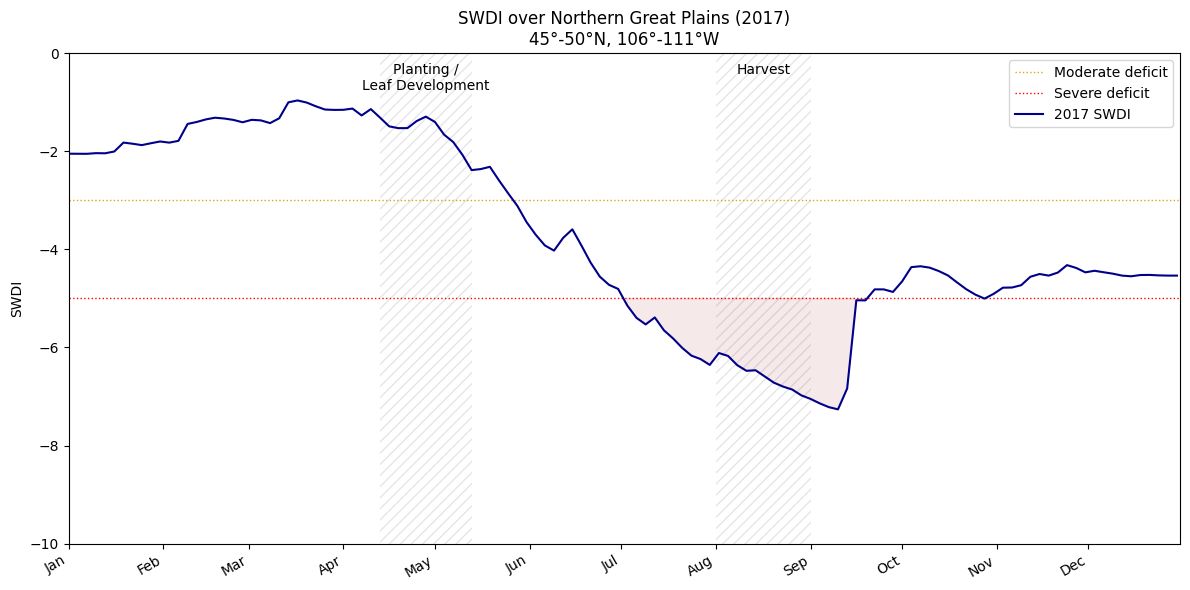

In [8]:
import csv
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

year = 2017
planting_start, planting_end = datetime(year, 4, 13), datetime(year, 5, 13) # noqa: DTZ001
harvest_start, harvest_end = datetime(year, 8, 1), datetime(year, 9, 1) # noqa: DTZ001


def add_crop_calendar(ax: plt.Axes, label: bool = True) -> None:
    """Cross-hatch the usual planting and harvest windows and label them on the plot."""
    ax.axvspan(planting_start, planting_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    ax.axvspan(harvest_start, harvest_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    if label:
        # x in data coordinates, y in axes-fraction coordinates
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        ax.text(planting_start + (planting_end - planting_start) / 2, 0.98, # type: ignore
                "Planting /\nLeaf Development", transform=trans, ha="center",
                va="top", fontsize=10, color="black")
        ax.text(harvest_start + (harvest_end - harvest_start) / 2, 0.98, # type: ignore
                "Harvest", transform=trans, ha="center", va="top",
                fontsize=10, color="black")

year = 2017
swdi_fname = f"data/swdi_timeseries_{year}.csv"
# Uncomment this line to compare the time series to another year
comparison_year = "" # "2016"


plot_dates = []
plot_swdi: list[float] = []
with open(swdi_fname, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        plot_dates.append(datetime.strptime(row["time"], "%Y-%m-%d")) # noqa: DTZ007
        plot_swdi.append(float(row["swdi"]))

# In this plot, we can highlight the period where the SWDI signal
# was indicating flash drought, i.e. it was persistently below -5
moderate_fd_thresh = -3
fd_thresh = -5
flash_drought_swdi = [r < fd_thresh for r in plot_swdi]

fig, ax = plt.subplots(figsize=(12, 6))
# Shade the usual planting and harvest windows for Spring Wheat and Barley
add_crop_calendar(ax)
ax.axhline(moderate_fd_thresh, color="goldenrod", linestyle=":", linewidth=1, label="Moderate deficit")
ax.axhline(fd_thresh, color="red", linestyle=":", linewidth=1, label="Severe deficit")
ax.plot(plot_dates, plot_swdi, color="darkblue", linewidth=1.5, label=f"{year} SWDI")

if comparison_year:
    swdi_comp_fname = f"data/swdi_timeseries_{comparison_year}.csv"
    plot_comp_swdi: list[float] = []
    with open(swdi_comp_fname, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            plot_comp_swdi.append(float(row["swdi"]))
    ax.plot(plot_dates, plot_comp_swdi, color="darkgreen", linewidth=1.5, label=f"{comparison_year} SWDI")

ax.set_ylim(-10, 0)
ax.set_xlim(left=mdates.datestr2num(f"{year}-01-01"), right=mdates.datestr2num(f"{year}-12-31")) # type: ignore
ax.fill_between(plot_dates, plot_swdi, fd_thresh, where=flash_drought_swdi, color="brown", alpha=0.1)
ax.set_ylabel("SWDI")
if comparison_year:
    title = f"SWDI over Northern Great Plains ({year} vs {comparison_year})\n45°-50°N, 106°-111°W"
else:
    title = f"SWDI over Northern Great Plains ({year})\n45°-50°N, 106°-111°W"
ax.set_title(title)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### What can we observe in the soil moisture data?

1. SWDI only began reporting a severe drought by July (denoted by the brown shaded region) and then recovered to moderate levels in the fall after the harvest due to above average rainfall. Recall that SIF-RCI began reporting a flash drought in early June. Does this mean that our soil moisture indicator was "too late" to report this flash drought before it became a problem? No, and as we will see in the part 2 notebook, proper use of SWDI requires considering its **rate of decline** in addition to the **length of time in drought**. Small excursions below the -3 or -5 thresholds for drought are not significant on their own.
2. Soil moisture is subject to rapid recovery due to precipitation, but is less sensitive to sudden changes in evaporative demand. While high evaporative stress can cause soil to dry out rapidly, SM and especially root zone SM change more slowly in response to developing drought conditions compared with ET. ET-based metrics like ESI and EDDI will swing between "drought" and "non-drought" states rapidly as weather conditions change. Root zone soil moisture can tell us how "vulnerable" cropland is to sustained dry conditions in the future. In other words, even though we might not be able to declare a severe drought from SWDI in June, the consistent negative trend and rate of decrease through the month (despite some precipitation) tells us that any further hot dry weather would push the region into an impactful drought.
3. If you run the previous cells again for the 2016 data (a non-drought year) and plot the comparison against 2017, you will see that some soil dry-down is expected during the growing season. While it would be preferable to compare the SM values against a long-baseline mean like we did with SIF, the 10-year record of SMAP is not long enough to give us a robust climatology. SWDI is intended to mitigate some of the disadvantages of not comparing against past behavior by **normalizing the estimates of soil moisture against the water carrying capacity of the local soil type**. Therefore, we can treat values below -5 as severe drought regardless of the source we use for deriving SWDI.

**NOTE:** In the approach we've shown, SWDI and SIF-RCI are meant to be used together to independently verify that flash drought conditions are developing or have occurred in a given region. Neither metric is "better" than the other, or should be thought of as having greater predictive skill. Rather, this technique considers a flash drought to be conditions where **soil moisture and SIF activity rapidly decrease below a threshold and stay persistently below that threshold during the growing season**.

The specific values of the threshold, the rate of decrease, and the growing season will depend on the region of interest and the definition used for flash drought. We will discuss ways of selecting these values in the second part.

### How close are these results to study this analysis is based on?

Finally, let's return to the study used as the basis of our approach and look at the time series in Figure 2b \[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\]. The scale for SWDI is on the right axis, while all other metrics use the left axis:

<div style="text-align:center">
  <img style="width:1024px" src="inputs/impactmatters_timeseries.png" alt="Plot of SIF-RCI, SWDI and other drought indicators during the 2017 Northern Great Plains flash drought event.">
</div>


It's important to note that our data sources are entirely different from those used by this study: the authors used GOME-2 for SIF, and an ensemble of three land surface models for soil mositure with no remote sensing measurements. Given that, the trends in the data (note the occurence of the high and low points of SIF-RCI and SWDI) are remarkably similar to our results. Although the values for SWDI in the study are consistently about 2 points lower than ours, the same decline (including a slight recovery in June and a greater recovery in September) can be observed in both. In fact if we use a threshold of -3 for flash drought in our own time series, SIF-RCI and SWDI began indicating flash drought around the same early June timeframe as the time series we obtained. You can also notice that the US Drought Monitor (USDM) only declared a severe drought by mid-late June, about 1 month after the two indicators we have been discussing.

With the benefit of hindsight, we can see that the soil moisture and SIF measurements provided several weeks of warning of the developing flash drought compared with the USDM, potentially giving an opportunity to make decisions about water purchases, crop futures, or other hedges against the economic impact of the event. This is the most important point: **there's no point in doing this analysis if the data is just telling us it's wet when it's raining** (or in our case, the opposite). The remote sensing approach needs to have a lead time over the information that everyone else has (the USDM) to be useful, which is what we have shown for this event. And remember, this is without even filtering by the land cover class! If you return to the SIF anomaly visualization at the beginning, look at how the anomaly was strongest over the croplands and grasslands, particularly in the northeastern portion of the study region. We stand to gain some SNR by ignoring the behavior of the forests, which are often more resilient to short duration droughts like the one in 2017. 

In practice, though, flash droughts can be recovered via a well-timed rainstorm just as quickly as they can develop, so it is not so simple to decide that an event is a flash drought as soon as these metrics fall below a given threshold. Judicious use of remote sensing data can provide a useful lead time over traditional signals like the USDM that other farmers or the broader commodities market may not have priced in. While high quality _in situ_ measurements, such as those used for precision agriculture, will outperform remote sensing and model-driven data in most cases, the approach we have shown is globally applicable.